In [16]:
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

num_samples = 1000
timesteps = 50
features = 1
latent_size = 16
batch_size = 32
epochs = 40
learning_rate = 0.01

X_clean = np.zeros((num_samples, timesteps, features))

time_step_axis = np.linspace(0, 4 * np.pi, timesteps)

for i in range(num_samples):
    phase_shift = np.random.uniform(0, 2 * np.pi)
    X_clean[i, :, 0] = np.sin(time_step_axis + phase_shift)

X_tensor = torch.FloatTensor(X_clean)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f'Dataset generated successfully!')
print(f'Shape of X_clean: {X_clean.shape}')

print(f"First 5 values of sample 0:\n{X_clean[0, :5, 0]}")

Dataset generated successfully!
Shape of X_clean: (1000, 50, 1)
First 5 values of sample 0:
[ 0.84170642  0.67722119  0.46843874  0.22901558 -0.02538755]


In [9]:
import torch.nn as nn
import torch

In [22]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, seq_len=50):
        super(LSTMAutoencoder, self).__init__()

        self.seq_len = seq_len
        
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.linear = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (hidden_state, _) = self.encoder(x)
        latent_vector = hidden_state[-1]

        repeated_vector = latent_vector.unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_out, _ = self.decoder(repeated_vector)

        out = self.linear(decoder_out)

        return out

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMAutoencoder(input_size=features, hidden_size=latent_size, seq_len=timesteps).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f'Starting Training on {device}...')
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.5f}")

Starting Training on cuda...
Epoch 10/40, Loss: 0.00179
Epoch 20/40, Loss: 0.00133
Epoch 30/40, Loss: 0.00024
Epoch 40/40, Loss: 0.00032


In [24]:
print("Evaluating model on noisy signal...")
model.eval()
with torch.no_grad():
    # A. Generate a brand new clean wave
    test_phase = np.random.uniform(0, 2 * np.pi)
    clean_wave = np.sin(time_step_axis + test_phase)
    
    # B. Add random gaussian noise to it
    noise = np.random.normal(0, 0.4, timesteps)
    noisy_wave = clean_wave + noise
    
    # C. Prepare tensor shape: [batch=1, timesteps=50, features=1]
    noisy_tensor = torch.FloatTensor(noisy_wave).unsqueeze(0).unsqueeze(-1).to(device)
    
    # D. Pass the noisy wave through the trained autoencoder
    reconstructed_tensor = model(noisy_tensor)
    
    # E. Squeeze back to 1D array for plotting
    reconstructed_wave = reconstructed_tensor.squeeze().cpu().numpy()

Evaluating model on noisy signal...


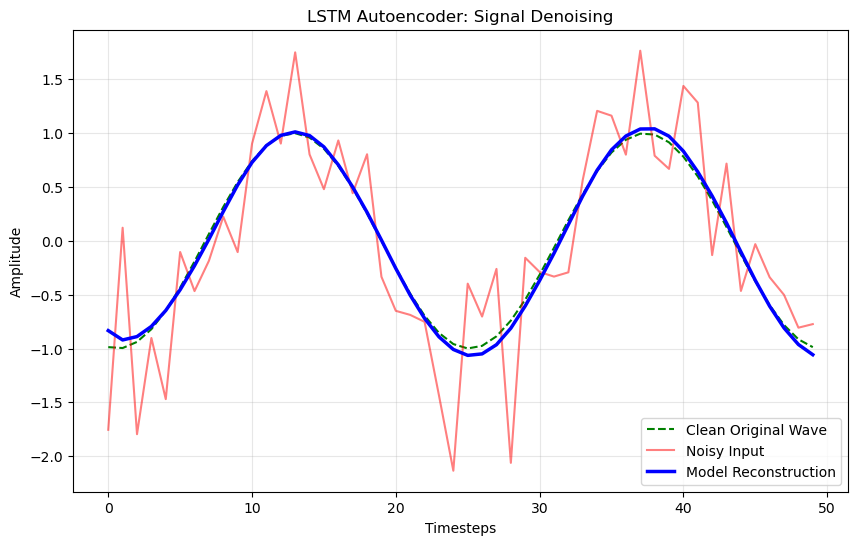

In [26]:
import matplotlib.pyplot as plt
# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(clean_wave, label="Clean Original Wave", linestyle='dashed', color='green')
plt.plot(noisy_wave, label="Noisy Input", alpha=0.5, color='red')
plt.plot(reconstructed_wave, label="Model Reconstruction", linewidth=2.5, color='blue')
plt.title("LSTM Autoencoder: Signal Denoising")
plt.xlabel("Timesteps")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(clean_wave, label="Clean Original Wave", linestyle='dashed', color='green')
plt.plot(noisy_wave, label="Noisy Input", alpha=0.5, color='red')
plt.plot(reconstructed_wave, label="Model Reconstruction", linewidth=2.5, color='blue')
plt.titlimesteps")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'clean_wave' is not defined

<Figure size 1000x600 with 0 Axes>